# Componentes de algoritmos de deep learning y Descenso del gradiente
Vamos a aplicar las piezas fundamentales de los algoritmos de Deep Learning para comprender como funciona la magia.

In [1]:
from typing import Any

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from numpy import dtype, float64, ndarray
from scipy.special import factorial

In [144]:
n_samples = 100
points = np.random.uniform(-1,1,n_samples)
gt_slope = -1.8
gt_bias = 0.4
y = gt_slope*points + gt_bias

class Perceptron:
    def __init__(self):
        self.bias = np.random.uniform(-3,3)
        self.slope = np.random.uniform(-3,3)
        self.last_input = np.random.uniform(-3, 3)

    def forward(self, x: npt.NDArray[np.float32|np.float64]) -> npt.NDArray[np.float32|np.float64]:
        self.last_input = x.copy()
        return self.slope*x + self.bias

    def backward(self, Derivate_error) -> npt.NDArray[np.float32|np.float64]:
        self.slope -= np.mean(Derivate_error * self.last_input)
        self.bias -= np.mean(Derivate_error)
        return np.mean(Derivate_error * self.last_input)

    def __str__(self):
        return "Perceptron: slope = {:.4f}, bias = {:.4f}".format(self.slope, self.bias)

class MSE:
    def __init__(self, learning_rate=0.5):
        self.last_input = None
        self.learning_rate = learning_rate
    def forward(self, y: npt.NDArray[np.float32|np.float64] ,
                y_pred: npt.NDArray[np.float32|np.float64] ) -> npt.NDArray[np.float32|np.float64]:
        self.last_input = y_pred
        self.last_gt  = y
        return (y-y_pred)**2 * self.learning_rate

    def backward(self, )-> npt.NDArray[np.float32|np.float64]:
        return (self.last_gt - self.last_input) * 2 * self.learning_rate * -1

    def __str__(self):
        return "MSE input = {:.4f}, derivative = {:.4f}".format(self.last_input, self.last_input * 2 * self.learning_rate)

perceptron = Perceptron()
loss = MSE()

pred_y = perceptron.forward(points[0])

error = loss.forward(y[0],pred_y)
print("error =  {:.4f}".format(error))



error =  0.0161


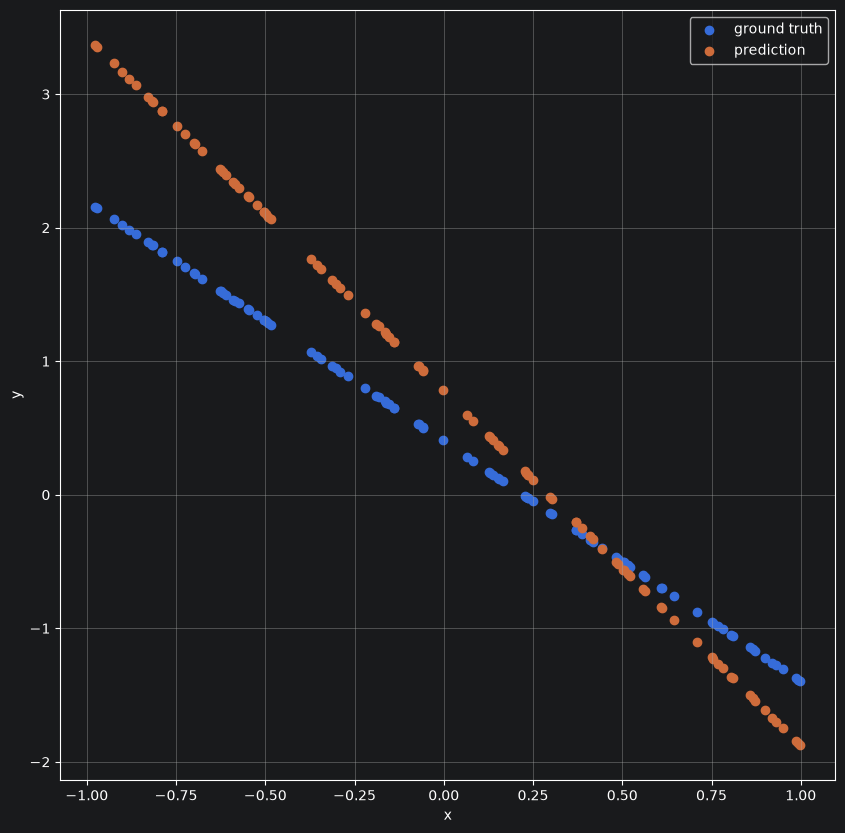

In [145]:
errors = np.empty([n_samples])
predictions = np.empty([n_samples])
for i,(x_point,y_point) in enumerate(zip(points,y)):
    pred_y = perceptron.forward(x_point)
    error = loss.forward(y_point,pred_y)

    errors[i] = error
    predictions[i] = pred_y



plt.figure(figsize=(10,10))
plt.scatter(points, y,label='ground truth')
plt.scatter(points, predictions,label='prediction')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.grid()

# Ejercicio
1. Grafica los puntos x,y de los datos generados.
2. Grafica las predicciones generadas por el model perceptron.
3. Calcula el error promedio de estos.
4. Realice predicciones muestra a muestra de los datos, y guarde los resultados.
5. Grafique el error.

perceptron data Perceptron: slope = -2.4821, bias = 2.7444
error 1.547
perceptron data Perceptron: slope = -3.9915, bias = 0.9853
error 0.015
perceptron data Perceptron: slope = -3.0946, bias = -0.6898
error 1.107
perceptron data Perceptron: slope = -2.2370, bias = 0.0139
error 0.000
perceptron data Perceptron: slope = -2.2615, bias = 0.0440
error 0.067
perceptron data Perceptron: slope = -1.4355, bias = 0.4662
error 0.011
perceptron data Perceptron: slope = -1.5228, bias = 0.6146
error 0.044
perceptron data Perceptron: slope = -1.9390, bias = 0.4291
error 0.005
perceptron data Perceptron: slope = -1.8454, bias = 0.5295
error 0.008
perceptron data Perceptron: slope = -1.7580, bias = 0.4802
error 0.007
perceptron data Perceptron: slope = -1.8539, bias = 0.3650
error 0.000
perceptron data Perceptron: slope = -1.8569, bias = 0.3946
error 0.000
perceptron data Perceptron: slope = -1.7798, bias = 0.3965


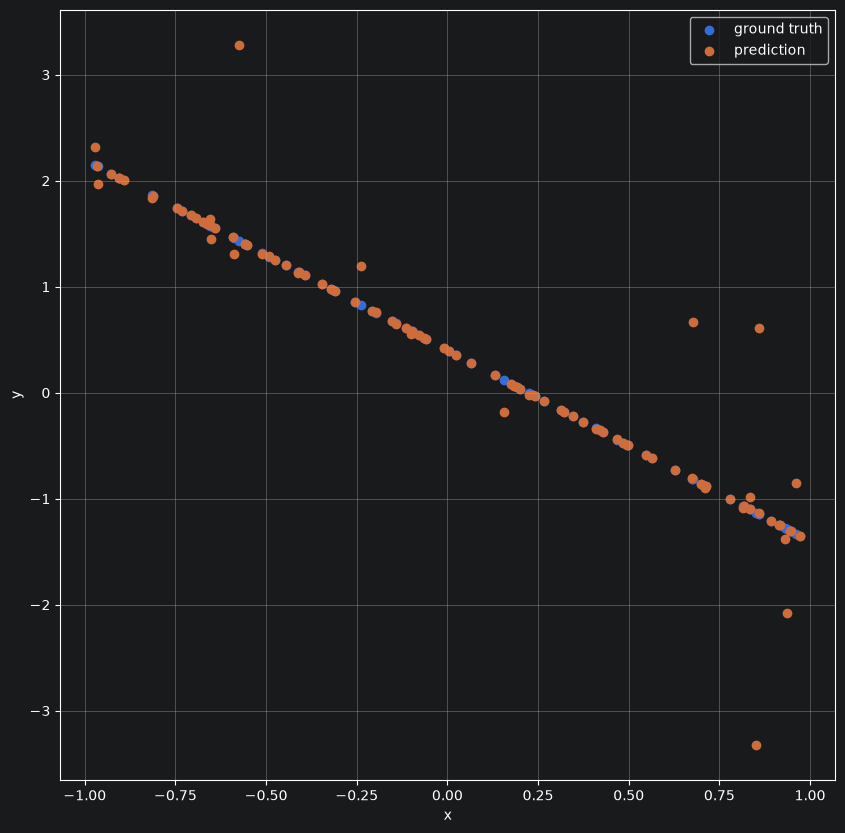

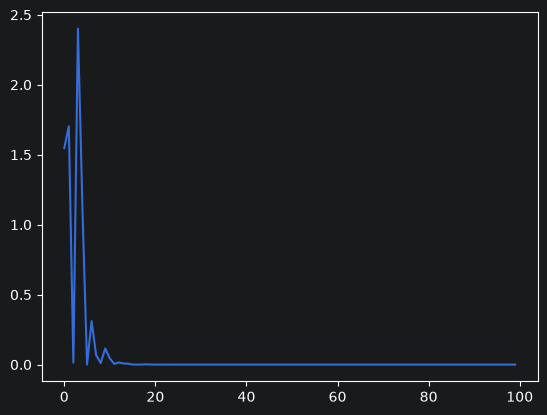

In [74]:
errors = np.empty([n_samples])
predictions = np.empty([n_samples])
# perceptron = Perceptron()
# loss = MSE(0.5)
epsilon = 0.001
print("perceptron data {}".format(perceptron))

for i, (x_point,y_point) in enumerate(zip(points, y)):
    pred_y = perceptron.forward(x_point)
    error = loss.forward(y_point,pred_y)
    derivative = loss.backward()
    perceptron.backward(derivative)
    errors[i] = error
    predictions[i] = pred_y

    if errors[i] < errors[i-1] - epsilon:
        print("error {:.3f}".format(errors[i]))
        print("perceptron data {}".format(perceptron))

plt.figure(figsize=(10,10))
plt.scatter(points, y,label='ground truth')
plt.scatter(points, predictions,label='prediction')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.grid()
plt.show()
plt.plot(errors)

## Predicciones mas complejas:

Ahora vamos a usar el algoritmo del descenso del gradiente para predecir una trayectoria mas compleja. En particular, vamos a usar las curvas polinomiales y de Bezier/Spline curves para generar datos y ver si nuestro algoritmo puede resolver el problema.

1. Grafique la curva polinomial.


In [140]:

a = -6
b = 6
c = -0.5
points = np.random.uniform(0,1,[n_samples,1])
curve = np.concat([points, points**2 * a + b * points + c],axis=1)


### Entrenamiento por batches/conjuntos

1. Entrene un modelo lineal.
2. Entrene un modelo polinomial de grado 2.
3. Modifique el numero de iteraciones, el learning_rate y

In [101]:
class PolinomialDegree2:
    def __init__(self):
        self.bias = np.random.uniform(-3,3)
        self.a = np.random.uniform(-3,3)
        self.b = np.random.uniform(-3,3)
        self.last_input = np.random.uniform(-3, 3)

    def forward(self, x: npt.NDArray[np.float32|np.float64]) -> npt.NDArray[np.float32|np.float64]:
        self.last_input = x.copy()
        return self.a*x**2 + self.b*x + self.bias

    def backward(self, Derivate_error) -> npt.NDArray[np.float32]:
        self.a -= np.mean(Derivate_error * self.last_input **2)
        self.b -= np.mean(Derivate_error * self.last_input)
        self.bias -= np.mean(Derivate_error)
        return np.array([Derivate_error * self.last_input**2, Derivate_error * self.last_input])

    def __str__(self):
        return "Polinomial: {:.4f} * x^2 + {:.4f} * x + {:.4f}".format(self.a, self.b, self.bias)



Polinomial: -0.3276 * x^2 + -1.3901 * x + 0.2981


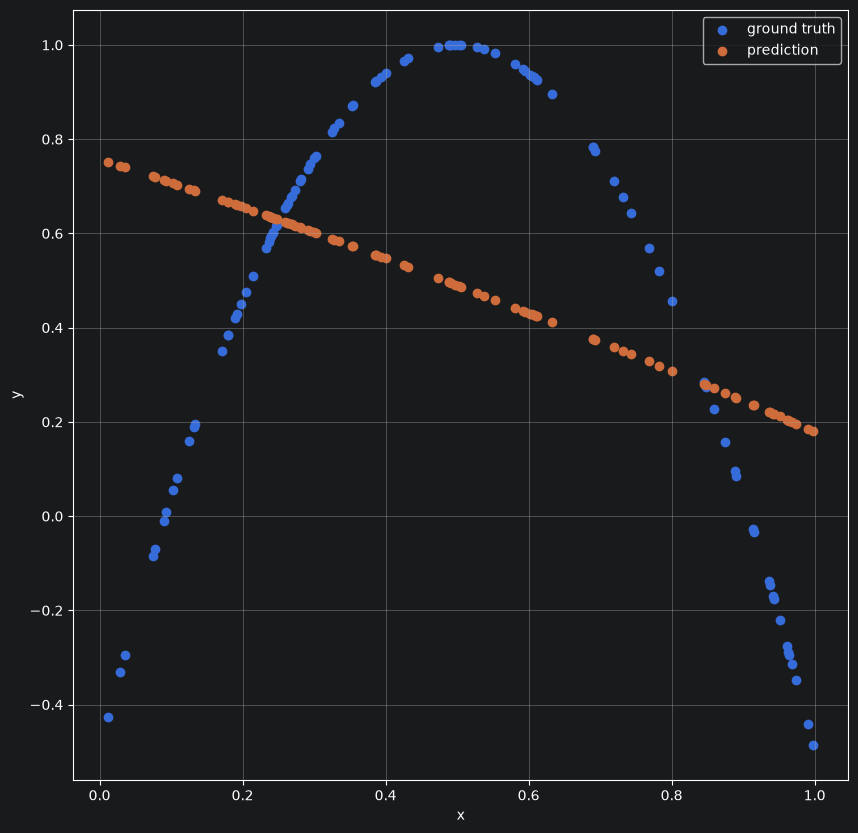

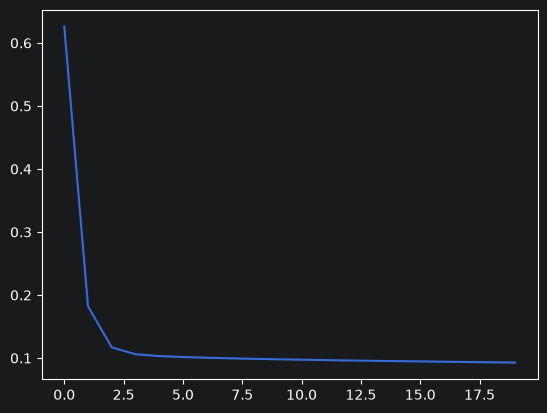

In [131]:
errors = np.zeros([n_samples]) + 10

model = PolinomialDegree2()
loss = MSE(0.5)
# epsilon = 0.0001
print("{}".format(model))
iterations = 20
errors = np.zeros([iterations])

for i in range(iterations):
    preds_y = model.forward(curve[:,0])
    error = loss.forward(curve[:,1],preds_y)
    derivative = loss.backward()

    errors[i] = np.mean(error)
    # break

    model.backward(derivative)
    # if errors[i] < epsilon:
    #     break
    if errors[i] > 500:
        break


predictions = model.forward(curve[:,0])
plt.figure(figsize=(10,10))
plt.scatter(curve[:,0], curve[:,1],label='ground truth')
plt.scatter(curve[:,0], predictions,label='prediction')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.grid()
plt.show()
plt.plot(errors)

### Curvas de Bézier
Las curvas de Bézier son curvas que se definen a partir de un conjunto de puntos de control. Estas curvas son útiles para representar formas complejas y suavizadas en gráficos y diseño gráfico. La ecuación de una curva de Bézier de grado n se puede expresar como una combinación lineal de los puntos de control, donde cada término está ponderado por un coeficiente binomial y una potencia de t y 1-t. La curva se forma al evaluar esta ecuación para diferentes valores de t en el intervalo [0, 1].

In [ ]:
def bezier_curve(control_points, num_points=100):
    """Calculates a Bezier curve from a set of control points."""
    n = len(control_points) - 1

    t = np.linspace(0, 1, num_points)
    curve = np.zeros((num_points, 2))

    for i in range(num_points):
        for j in range(n + 1):
            curve[i] += (
                control_points[j]
                * (
                    factorial(n)
                    / (factorial(j) * factorial(n - j))
                )
                * t[i] ** j
                * (1 - t[i]) ** (n - j)
            )
    return curve

# Example control points
control_points = np.array([[0, 0], [1, 2], [3, 1], [4, 0]])
curve = bezier_curve(control_points)
# print(curve)
plt.plot(curve[:, 0], curve[:, 1])  # Plot the curve
plt.scatter(control_points[:, 0], control_points[:, 1])  # Plot control points
plt.show()

Polinomial: -1.4375 * x^2 + 1.3403 * x + -1.7973


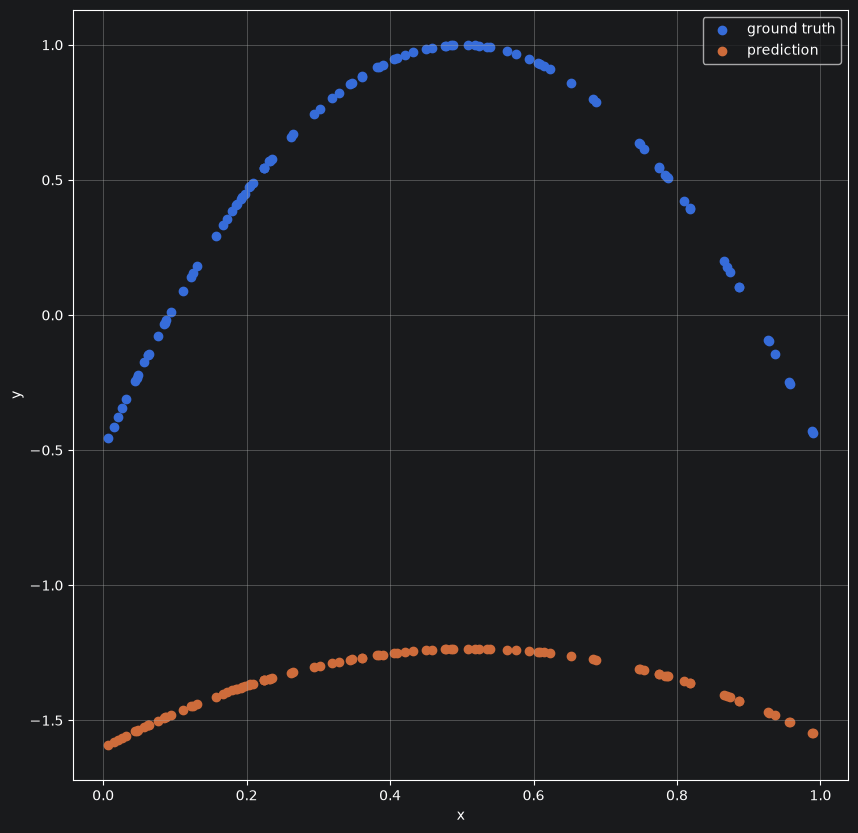

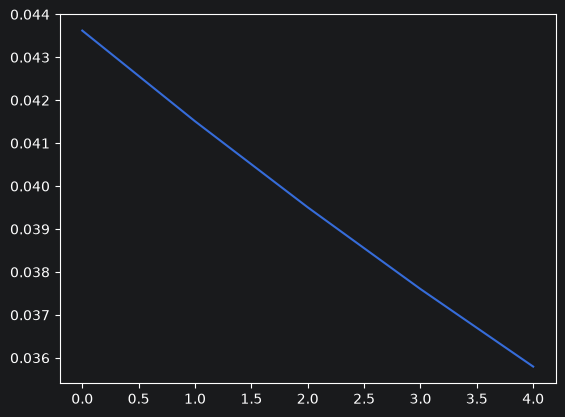

In [141]:
errors = np.zeros([n_samples]) + 10

model = PolinomialDegree2()
loss = MSE(0.01)
# epsilon = 0.0001
print("{}".format(model))
iterations = 5
errors = np.zeros([iterations])

for i in range(iterations):
    preds_y = model.forward(curve[:,0])
    error = loss.forward(curve[:,1],preds_y)
    derivative = loss.backward()

    errors[i] = np.mean(error)
    # break

    model.backward(derivative)
    # if errors[i] < epsilon:
    #     break
    if errors[i] > 500:
        break


predictions = model.forward(curve[:,0])
plt.figure(figsize=(10,10))
plt.scatter(curve[:,0], curve[:,1],label='ground truth')
plt.scatter(curve[:,0], predictions,label='prediction')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.grid()
plt.show()
plt.plot(errors)

### Entrenamiento Estocástico
1. Realice un entrenamiento muestra a muestra.
2. Comente sobre el resultado y la curva  de error.

perceptron data Polinomial: -1.9724 * x^2 + -1.6145 * x + 0.4422


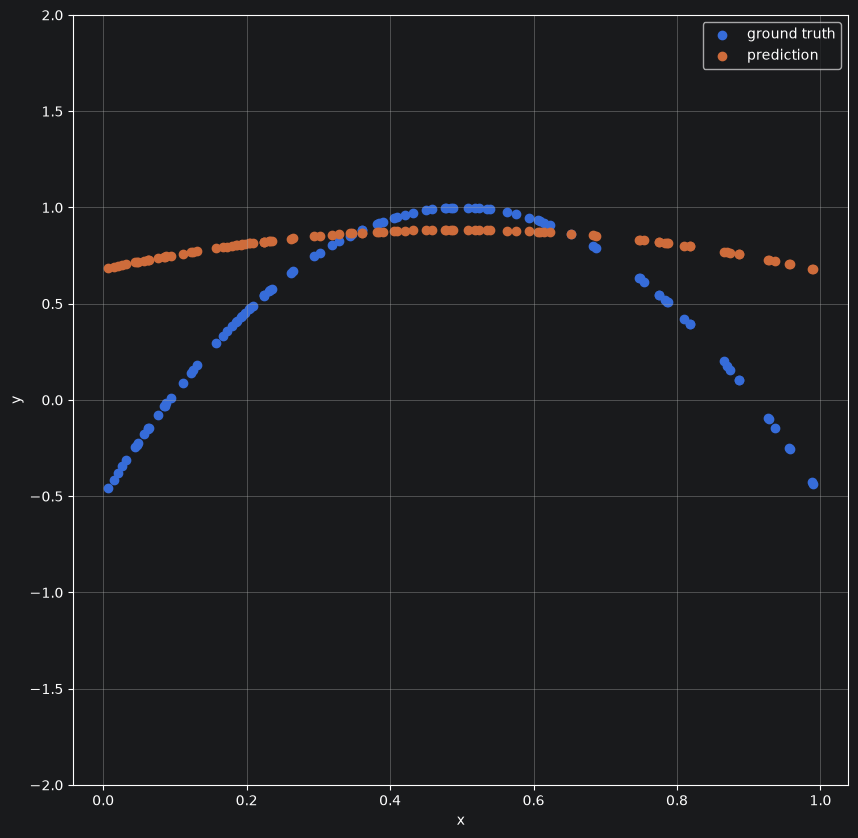

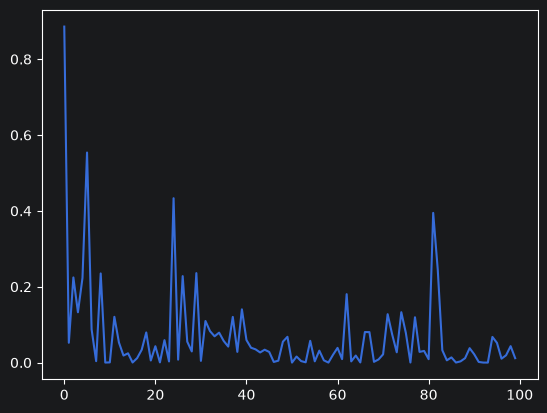

In [143]:

errors = np.zeros([n_samples]) + 10
# predictions = np.zeros([n_samples])
model = PolinomialDegree2()
loss = MSE(0.2)
epsilon = 100
print("perceptron data {}".format(model))

for i, (x_point,y_point) in enumerate(curve):

    pred_y = model.forward(x_point)
    error = loss.forward(y_point,pred_y)
    derivative = loss.backward()

    errors[i] = error
    # predictions[i] = pred_y
    if errors[i] > 500:
        print("Inconsistency at {:d}".format(i))
        print(errors[i-1], errors[i], errors[i+1])
        errors[(i):] = errors[i-1]
        predictions[i:] = model.forward(curve[i:,0])
        break
    model.backward(derivative)
    # if errors[i] < errors[i-1] - epsilon:
    # print("error {:.3f}".format(errors[i]))
    # if i > 10:
    #     break

plt.figure(figsize=(10,10))
predictions = model.forward(curve[:,0])
plt.scatter(curve[:,0], curve[:,1],label='ground truth')
plt.scatter(curve[:,0], predictions,label='prediction')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
plt.ylim([-2,2])
plt.grid()
plt.show()
plt.plot(errors)